In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import poseidon_core
import poseidon_utils

 Platform does not have any supported GPU!
 Platform verification failed
 platform is not supported by cufile
 cuFile initialization failed


In [40]:
file_path = '../data/lidar/combined_point_cloud_down_east.laz'
# file_path = "../data/lidar/Job1051007_34077_04_88.laz"

min_x_extent = 847809.694
max_x_extent = 847973.874
min_y_extent = 127254.634
max_y_extent = 127450.141

# min_x_extent = 712160
# max_x_extent = 712230
# min_y_extent = 33100
# max_y_extent = 33170

grid_gen = poseidon_core.GridGenerator(
    file_path,
    min_x_extent,
    max_x_extent,
    min_y_extent,
    max_y_extent,
    lidar_units="meters",
)

resolution = 0.05  # meters

pts_array = grid_gen.create_point_array()
grid_x, grid_y, grid_z = grid_gen.gen_grid(
    resolution, pts_array, grid_descriptor="carolina_beach"
)


--- Starting grid generation for 'carolina_beach' at 0.05m ---
  [IO] Using existing directory: data/generated_grids
  [GRID] Generating grid coordinates...
    X Extent: 847809.69 to 847973.87
    Y Extent: 127254.63 to 127450.14
    Initial grid shape (before transpose): (3284, 3911)
  [GRID] Interpolating Z grid from 205550 input points...
    [WARN] 8834 grid points were outside the interpolation area (set to NaN).
  [GRID] Transposing grids to (Y, X) convention.
    Final grid shape: (3911, 3284)
  [IO] Saving compressed Zarr arrays (mode='w', overwriting)...
    X -> data/generated_grids/carolina_beach_grid_x_0.05m.zarr
    Y -> data/generated_grids/carolina_beach_grid_y_0.05m.zarr
    Z -> data/generated_grids/carolina_beach_grid_z_0.05m.zarr
--- Grid generation successful in 5.27 seconds. ---


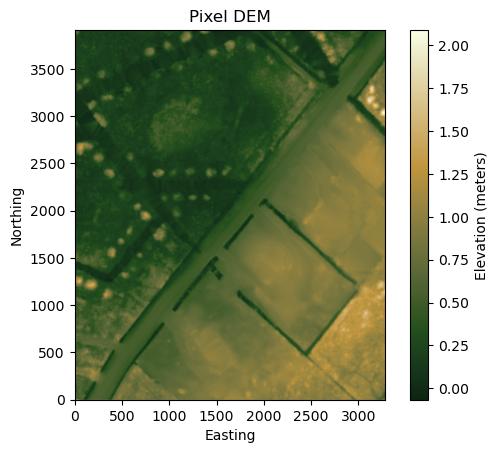

In [41]:
# Visualize the elevation grid
grid_gen.plot_elev_grid(grid_z)

In [42]:
intrinsics = np.array(
    [
        3040,  # number of pixel columns
        4056,  # number of pixel rows
        1503.0136,  # U component of principal point
        2163.4301,  # V component of principal point
        2330.4972,  # U component of focal length
        2334.0017,  # V component of focal length
        -0.3587,  # radial distortion
        0.1388,  # radial distortion
        -0.0266,  # radial distortion
        -0.0046,  # tangential distortion
        0.0003,  # tangential distortion
    ]
)

extrinsics = np.array([847955.4296, # camera x in world
                       127408.728, # camera y in world
                       4.4922, # camera elev in world
                       4.38504, # azimuth
                       1.14484, # tilt
                       0.01305 # roll/swing
                       ])
# extrinsics = np.array(
#     [
#         712159.597863065,  # camera x in world
#         33136.9994153273,  # camera y in world
#         3.72446811607855,  # camera elev in world
#         1.30039127961854,  # azimuth
#         1.02781393967485,  # tilt
#         -0.160877893129538,  # roll/swing
#     ]
# )

In [46]:
rectifier = poseidon_core.ImageRectifier(
    intrinsics, extrinsics, grid_x, grid_y, grid_z, use_gpu=True
)

rect_im = rectifier.merge_rectify(
    "../data/CAM_DE_01_20241020151826.jpg", verbose=True
)

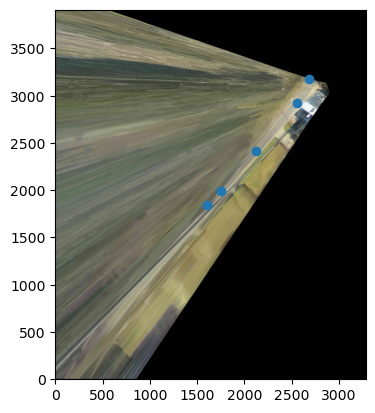

In [59]:
plt.imshow(rect_im, origin='lower')
# plt.scatter(virtual_sensor_locs[:,0], virtual_sensor_locs[:,1])
plt.scatter(new_sensor_locs[:,0], new_sensor_locs[:,1])
plt.show()

In [ ]:
virtual_sensor_locs = np.array([[125, 390], [75, 440], [5, 370], [9, 355]]) * 2

In [51]:
height = flipped_array.shape[0]

In [52]:
height

3911

In [57]:
3911-983

2928

In [58]:
new_sensor_locs = np.array([[1610, 1847], [2682, 3176], [1756, 1990], [2120, 2414], [2556, 2928]])

In [24]:
virtual_sensor_locs

array([[250, 780],
       [150, 880],
       [ 10, 740],
       [ 18, 710]])

In [48]:
rect_im = rect_im.get()

In [49]:
flipped_array = rect_im[::-1, :, :]

In [50]:
plt.imsave('DE_rectified.png', flipped_array)

In [ ]:
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import box
import geopandas as gpd
import rasterio
from rasterio.plot import show as rioshow

# --- CONFIGURATION ---
# Use the same extents you use on the HPC
# min_x, max_x = 847809.694, 847973.874
# min_y, max_y = 127254.634, 127450.141
min_x, max_x = 712160, 712230
min_y, max_y = 33100, 33170
crs = "EPSG:32119"
output_filename = "DE_01_basemap.tif"

def download_basemap():
    print(" defining extent...")
    # Create a geometry for your extent
    bbox = box(min_x, min_y, max_x, max_y)
    gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs=crs)

    # Convert to Web Mercator (EPSG:3857) because contextily requires it
    gdf_mercator = gdf.to_crs(epsg=3857)
    
    # Get the bounds in Web Mercator
    w, s, e, n = gdf_mercator.total_bounds
    
    print("Fetching tiles from Esri World Imagery...")
    # Download the image
    # zoom=19 is very high res; lower it (e.g., 16-18) if the file is too huge
    image, image_extent = ctx.bounds2img(w, s, e, n, zoom=19, source=ctx.providers.Esri.WorldImagery)

    print(f"Saving to {output_filename}...")
    # Contextily returns a numpy array and an extent. 
    # We need to save this as a GeoTIFF properly.
    # Note: contextily returns (channels, height, width) or (height, width, channels) depending on version.
    # Usually it is (H, W, C). Rasterio expects (C, H, W).
    
    if image.shape[2] == 3 or image.shape[2] == 4:
        image = image.transpose(2, 0, 1)

    # Calculate transform
    # image_extent is [left, right, bottom, top]
    # We need pixel width/height
    # width in pixels is image.shape[2]
    # height in pixels is image.shape[1]
    
    pixel_width = (image_extent[1] - image_extent[0]) / image.shape[2]
    pixel_height = (image_extent[3] - image_extent[2]) / image.shape[1]
    
    transform = rasterio.transform.from_origin(
        image_extent[0], image_extent[3], pixel_width, pixel_height
    )

    with rasterio.open(
        output_filename,
        'w',
        driver='GTiff',
        height=image.shape[1],
        width=image.shape[2],
        count=3, # RGB
        dtype=image.dtype,
        crs='EPSG:3857',
        transform=transform,
    ) as dst:
        dst.write(image[:3, :, :]) # Write RGB, ignore Alpha if present

    print("Done!")

if __name__ == "__main__":
    download_basemap()

 defining extent...
Fetching tiles from Esri World Imagery...
Saving to DE_01_basemap.tif...
Done!
